# 1. 임베딩 내 편향성 알아보기
잘못된 머신러닝 학습에 대한 유명한 사례로 '차량 충돌 사고 실험'이 있습니다. 한 데이터 제조업체에서 충돌 실험을 통해 탑승자의 신체 움직임을 파악하고 안전성을 높이고자 했습니다. 그러나 결과적으로 여성 탑승자가 남성 탑승자보다 사망률이 높았다고 합니다. 왜 그런 걸까요? 차량 실험에서 쓰인 데이터가 남성 위주였기 때문입니다. 데이터로부터 편향성 이 생긴 경우입니다. 

데이터를 기반으로 하는 인공지능에 대해 생각해 봅시다. 만약 우리가 가진 데이터가 이미 편향되어 있다면 이를 이용하여 만든 알고리즘 또한 편향될 확률이 매우 높습니다. 그래서 최근에는 인공지능이 가진 편향성을 예방하기 위한 연구가 지속되고 있습니다. 특히 자연어처리 분야, 그중에서도 워드 임베딩과 관련된 연구가 많이 이루어지고 있습니다. 

그래서 오늘은 워드 임베딩에 숨어 있는 편향성을 측정하는 대표적인 방법론인 Word Embedding Association Test (WEAT) 라는 기법에 대해 알아보고, 이를 활용해 우리가 학습시킨 Word2Vec 임베딩 내의 편향성을 측정해 보면서 실제로 이 방법론이 우리 머리 속에 있는 편향성을 잘 반영하는지도 살펴보겠습니다.

# 워드 임베딩 속의 편향성
'프로그래머'라는 단어에서 남성의 이미지가, '가정주부'라는 단어에서 여성의 이미지가 떠오르시나요? 분명 프로그래머와 가정주부는 젠더 중립적인 단어임에도 불구하고 우리의 무의식 속에서 어쩌면 정말 그렇게 느끼고 있을지도 모르겠군요.
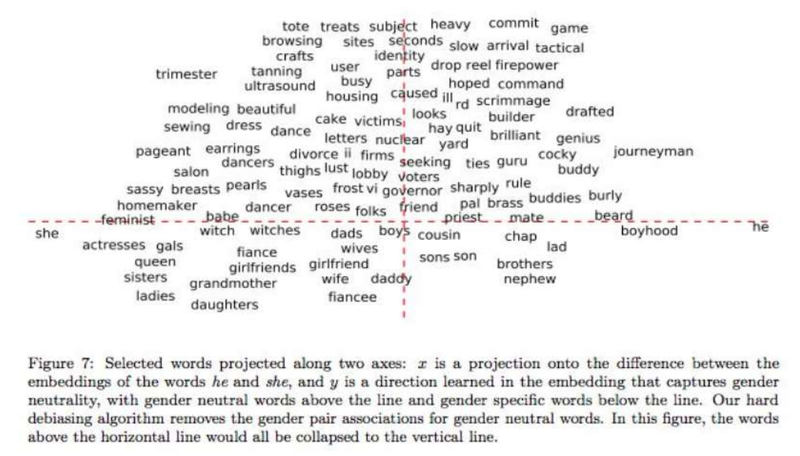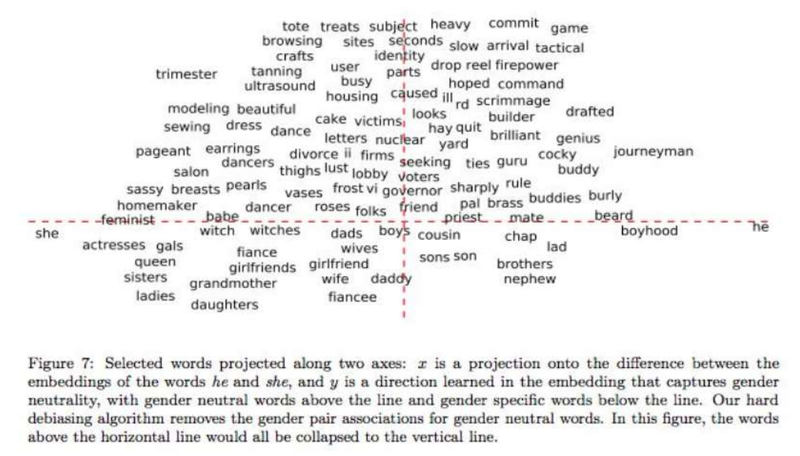


# WEAT(Word Embedding Association Test)
워드 임베딩 벡터들 간에는 의미적인 유사도 거리를 정량적으로 측정할 수 있습니다. 그렇다면 워드 임베딩에 내포된 편향성도 정량적으로 측정할 방법은 없을까요? 위 논문이 발표되자마자 몇 달도 되지 않아 그런 방법이 제안되었습니다. 

Science를 대표하는 target 단어 셋 X와 Art를 대표하는 target 단어 셋 Y가 있다고 하면 X-Y 셋을 통한 개념축 하나가 얻어집니다. Male을 대표하는 attribute 단어 셋 A와 Female을 대표하는 attribute 단어 셋 B가 있다면 A-B 셋을 통한 개념축 하나가 또 얻어집니다. 편향성이 없다면, X에 속한 단어들은 A에 속한 단어들과의 거리와 B에 속한 단어들과의 거리가 별 차이가 없어야 합니다. 반대의 경우라면 뚜렷하게 차이가 나겠죠. Y의 경우도 마찬가지입니다. 



다음 스텝에 수식을 통해 보다 명확하게 설명할 WEAT score는 바로 위와 같은 방식으로 계산된 수치입니다. 절댓값이 클수록 두 개념축 사이의 편향성이 크게 나타나는 것으로 해석됩니다.

💡 WEAT의 target과 attribute 개념 정리
WEAT(Word Embedding Association Test)는 두 가지 성격의 단어 셋(Set)을 비교하여 임베딩 공간 내의 편향성을 측정합니다.

Target (타겟 단어 셋): * 편향성을 검사하고자 하는 '분석 대상' 개념입니다.

서로 대비되는 두 개의 축으로 구성됩니다. (예: Science(과학) vs Art(예술))

Attribute (속성 단어 셋): * 타겟 단어들이 어느 쪽으로 치우쳤는지 판단하는 '기준(잣대)'이 되는 개념입니다.

사회적 편견이나 관념을 담고 있는 두 개의 축으로 구성됩니다. (예: Male(남성) vs Female(여성))

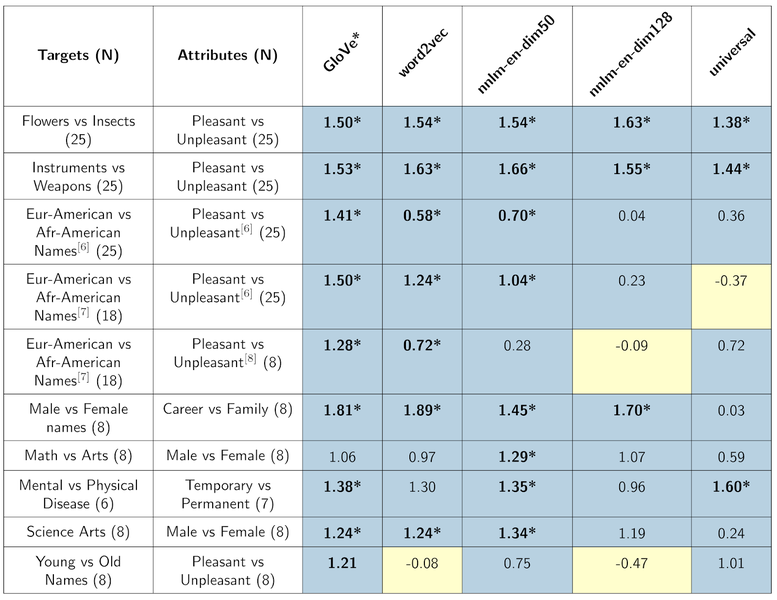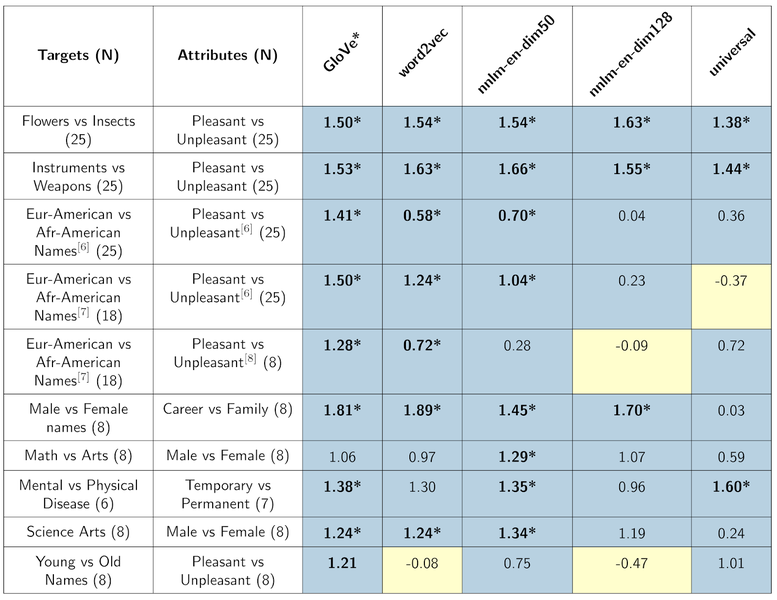

표에서 파란색은 사람의 편향과 같은 경우이고, 노란색은 사람의 편향과 반대인 경우를 의미합니다. (사람이 가진 편향은 Implicit Association Tests로 측정했습니다.) 

Glove, Word2Vec 등 다양한 워드 임베딩 모델에 대해 동일한 실험을 하여 WEAT score를 측정해 본 결과도 흥미롭습니다. 모델마다 WEAT score가 동일하게 나오는 것이 아닙니다. 이런 차이점의 원인을 분석해 보는 것도 흥미로울 것 같습니다.

# 3. WEAT를 통한 편향성 측정
WEAT score는 다음과 같이 정의합니다.
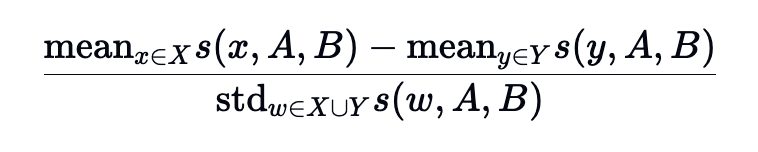

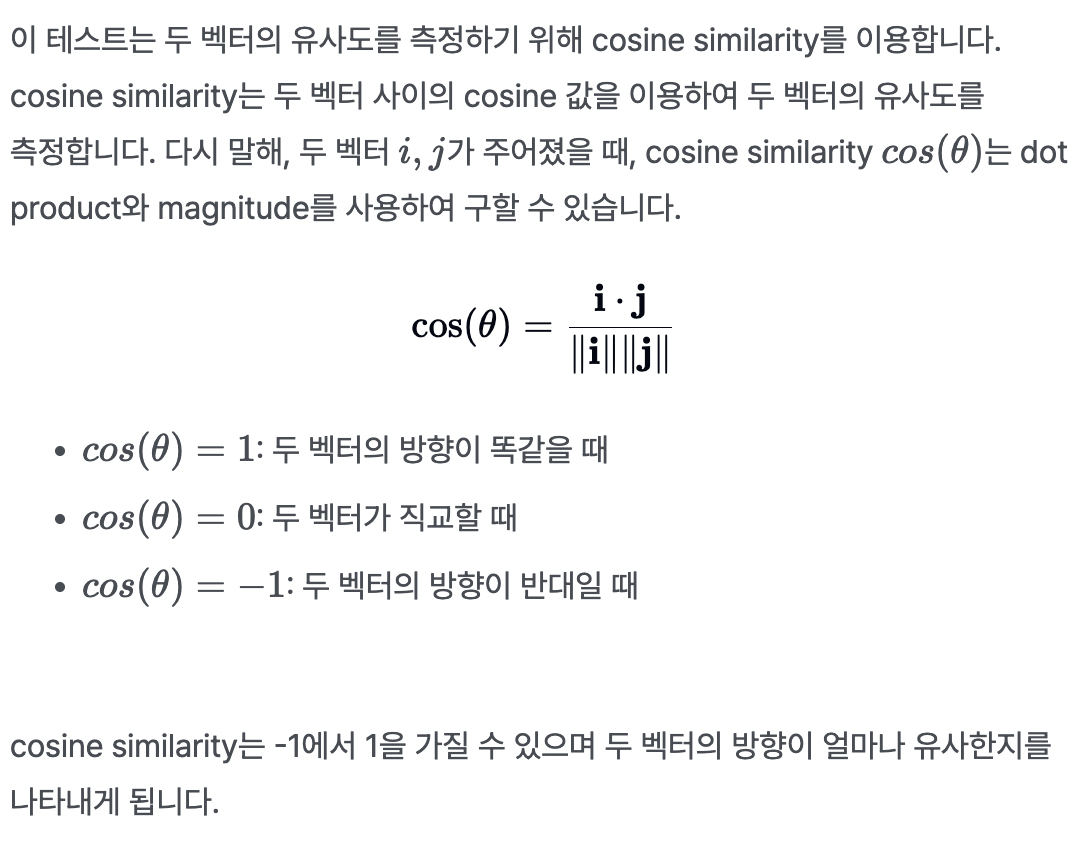

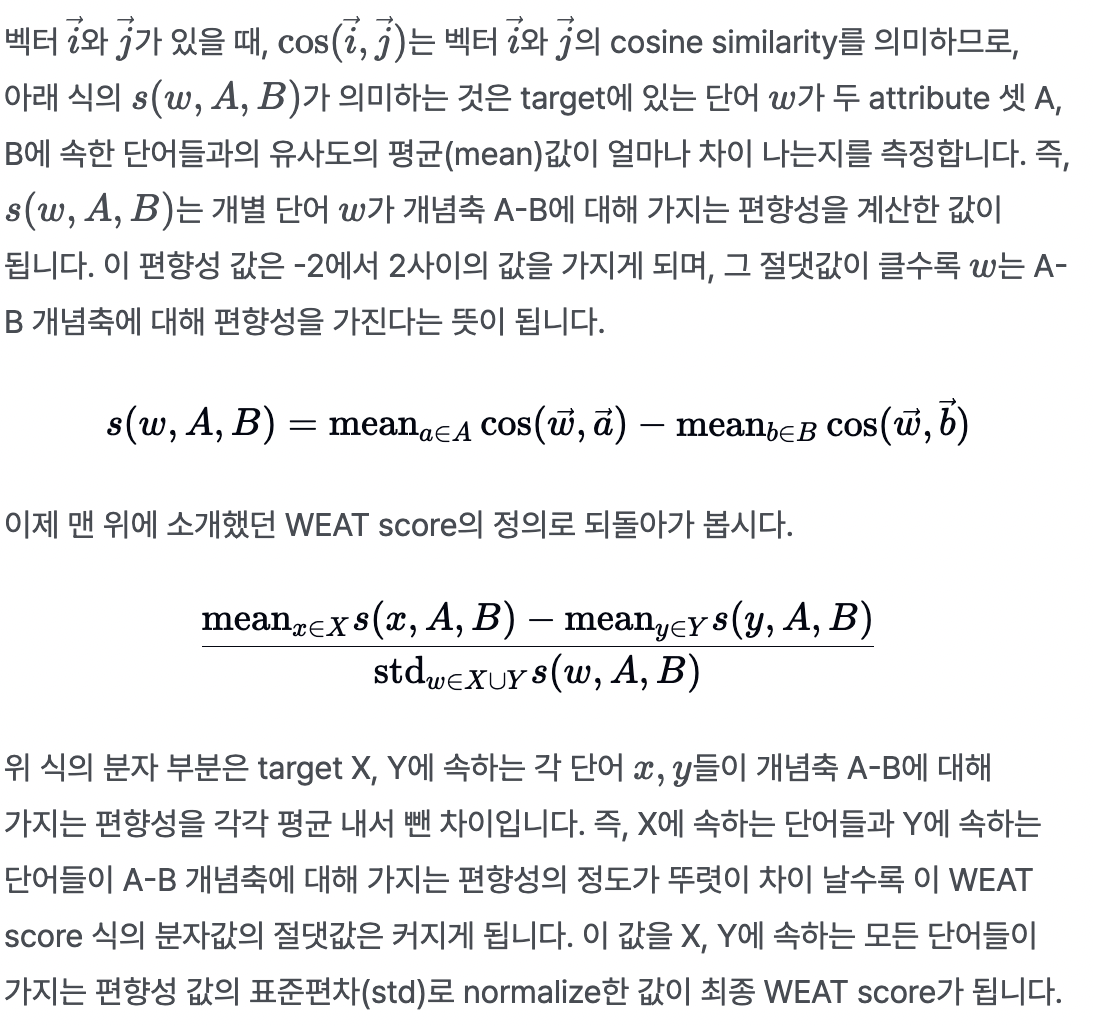


In [1]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

print("슝~")

슝~


우선 두 개의 target 단어 셋 X, Y와 두 개의 attribute 단어 셋 A, B를 정의합니다. 

단어 셋을 정할 때는 두 개의 target 셋의 크기가 같아야 하고, 두 개의 attribute 셋의 크기가 같아야 합니다.


targets
X set(꽃) : 장미, 튤립, 백합, 데이지
Y set(곤충) : 거미, 모기, 파리, 메뚜기
attributes
A set(유쾌) : 사랑, 행복, 웃음
B set(불쾌) : 재난, 고통, 증오

위 단어들의 임베딩 결과가 다음과 같다고 해봅시다.

In [2]:
target_X = {
    '장미': [4.1, 1.2, -2.4, 0.5, 4.1],
    '튤립': [3.1, 0.5, 3.6, 1.7, 5.8],
    '백합': [2.9, -1.3, 0.4, 1.1, 3.7],
    '데이지': [5.4, 2.5, 4.6, -1.0, 3.6]
}
target_Y = {
    '거미': [-1.5, 0.2, -0.6, -4.6, -5.3],
    '모기': [0.4, 0.7, -1.9, -4.5, -2.9],
    '파리': [0.9, 1.4, -2.3, -3.9, -4.7],
    '메뚜기': [0.7, 0.9, -0.4, -4.1, -3.9]
}
attribute_A = {
    '사랑':[2.8,  4.2, 4.3,  0.3, 5.0],
    '행복':[3.8,  3. , -1.2,  4.4, 4.9],
    '웃음':[3.7, -0.3,  1.2, -2.5, 3.9]
}
attribute_B = {
    '재난': [-0.2, -2.8, -4.7, -4.3, -4.7],
    '고통': [-4.5, -2.1,  -3.8, -3.6, -3.1],
    '증오': [-3.6, -3.3, -3.5,  -3.7, -4.4]
}

print("슝~")

슝~


In [3]:
X = np.array([v for v in target_X.values()])
Y = np.array([v for v in target_Y.values()])
print(X)
print(Y)

[[ 4.1  1.2 -2.4  0.5  4.1]
 [ 3.1  0.5  3.6  1.7  5.8]
 [ 2.9 -1.3  0.4  1.1  3.7]
 [ 5.4  2.5  4.6 -1.   3.6]]
[[-1.5  0.2 -0.6 -4.6 -5.3]
 [ 0.4  0.7 -1.9 -4.5 -2.9]
 [ 0.9  1.4 -2.3 -3.9 -4.7]
 [ 0.7  0.9 -0.4 -4.1 -3.9]]


In [4]:
target_X = {
    '장미': [4.1, 1.2, -2.4, 0.5, 4.1],
    '튤립': [3.1, 0.5, 3.6, 1.7, 5.8],
    '백합': [2.9, -1.3, 0.4, 1.1, 3.7],
    '데이지': [5.4, 2.5, 4.6, -1.0, 3.6]
}
target_Y = {
    '거미': [-1.5, 0.2, -0.6, -4.6, -5.3],
    '모기': [0.4, 0.7, -1.9, -4.5, -2.9],
    '파리': [0.9, 1.4, -2.3, -3.9, -4.7],
    '메뚜기': [0.7, 0.9, -0.4, -4.1, -3.9]
}
attribute_A = {
    '사랑':[2.8,  4.2, 4.3,  0.3, 5.0],
    '행복':[3.8,  3. , -1.2,  4.4, 4.9],
    '웃음':[3.7, -0.3,  1.2, -2.5, 3.9]
}
attribute_B = {
    '재난': [-0.2, -2.8, -4.7, -4.3, -4.7],
    '고통': [-4.5, -2.1,  -3.8, -3.6, -3.1],
    '증오': [-3.6, -3.3, -3.5,  -3.7, -4.4]
}

print("슝~")

슝~


In [5]:
X = np.array([v for v in target_X.values()])
Y = np.array([v for v in target_Y.values()])
print(X)
print(Y)

[[ 4.1  1.2 -2.4  0.5  4.1]
 [ 3.1  0.5  3.6  1.7  5.8]
 [ 2.9 -1.3  0.4  1.1  3.7]
 [ 5.4  2.5  4.6 -1.   3.6]]
[[-1.5  0.2 -0.6 -4.6 -5.3]
 [ 0.4  0.7 -1.9 -4.5 -2.9]
 [ 0.9  1.4 -2.3 -3.9 -4.7]
 [ 0.7  0.9 -0.4 -4.1 -3.9]]


In [6]:
A = np.array([v for v in attribute_A.values()])
B = np.array([v for v in attribute_B.values()])
print(A)
print(B)

[[ 2.8  4.2  4.3  0.3  5. ]
 [ 3.8  3.  -1.2  4.4  4.9]
 [ 3.7 -0.3  1.2 -2.5  3.9]]
[[-0.2 -2.8 -4.7 -4.3 -4.7]
 [-4.5 -2.1 -3.8 -3.6 -3.1]
 [-3.6 -3.3 -3.5 -3.7 -4.4]]


WEAT score값이 양수이므로, target_X에 있는 '장미'라는 단어는 attribute_B(불쾌)보다 attribute_A(유쾌)와 더 가깝다는 것을 알 수 있습니다. target_Y에 있는 '거미'와 attribute_A, attribute_B와의 관계도 계산해봅시다.



In [7]:
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B #, c_a, c_b

print(s(target_X['장미'], A, B))

0.6457646122337399


In [8]:
print(s(target_Y['거미'], A, B))

-0.794002342033094


위와 반대로 WEAT score가 음수가 나왔으므로, '거미'는 attribute_B와 더 가깝다는 것을 알 수 있습니다. 



그럼 target_X와 attribute_A, attribute_B 사의의 평균값, 그리고 target_Y와 attribute_A, attribute_B 사의의 평균값은 어떻게 될까요

In [9]:
print(s(X, A, B))
print(round(np.mean(s(X, A, B)), 3))

[0.29551989 0.51723181 0.26499096 0.50924109]
0.397


In [10]:
print(s(Y, A, B))
print(round(np.mean(s(Y, A, B)), 3))

[-0.44713039 -0.28310853 -0.33144878 -0.26030641]
-0.33


그럼 이번에는 WEAT score의 수식 전체를 코드로 나타내 봅시다.
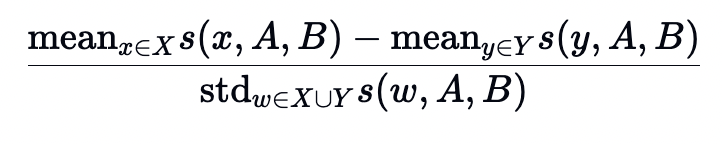

In [12]:
def weat_score(X, Y, A, B):

    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

print(round(weat_score(X, Y, A, B), 3))

1.932


WEAT score가 매우 높게 나온 것을 알 수 있습니다. 즉, 꽃은 유쾌한 단어와 상대적으로 가깝고, 곤충은 불쾌한 단어와 가깝다는 것을 수치적으로 확인할 수 있었습니다. 



이제 이를 시각적으로 확인해볼까요? PCA를 통해 5차원이었던 벡터를 2차원으로 줄여 그림을 그려보겠습니다.

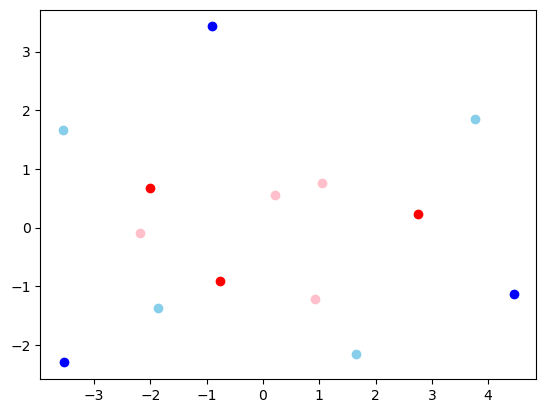

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pc_A = pca.fit_transform(A)
pc_B = pca.fit_transform(B)
pc_X = pca.fit_transform(X)
pc_Y = pca.fit_transform(Y)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(pc_A[:,0],pc_A[:,1], c='blue', label='A')
ax.scatter(pc_B[:,0],pc_B[:,1], c='red', label='B')
ax.scatter(pc_X[:,0],pc_X[:,1], c='skyblue', label='X')
ax.scatter(pc_Y[:,0],pc_Y[:,1], c='pink', label='Y')

파란색 점(A)과 하늘색 점(X)이 가깝고, 빨간색 점(B)과 분홍색 점(Y)이 가깝게 표현된 것을 확인할 수 있습니다.